# ITAI 1371 ML Final
## HR Analytics: Job Change of Data Scientists

**Kaggle dataset:** https://www.kaggle.com/datasets/arashnic/hr-analytics-job-change-of-data-scientists/data

This notebook studies the HR Analytics Job Change of Data Scientists dataset. The target variable is whether a candidate is likely to look for a new job.

### 1. Import Required Libraries


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Show all columns when displaying DataFrames
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)


### 2. Load the Raw Dataset

In [3]:
# Possible dataset paths for local work, repository structure, or Colab
possible_paths = [
    Path('data/raw/aug_train.csv'),
    Path('../data/raw/aug_train.csv'),
    Path('/content/project/ITAI-1371_Mid_Term_EDA_Group_ML_19179_3/data/raw/aug_train.csv'),
    Path('/content/aug_train.csv'),
]

DATA_PATH = None

# Check common expected locations first
for candidate in possible_paths:
    if candidate.exists():
        DATA_PATH = candidate.resolve()
        break

# If not found, search recursively in the current working directory
if DATA_PATH is None:
    matches = list(Path('.').rglob('aug_train.csv'))
    if matches:
        DATA_PATH = matches[0].resolve()
    else:
        raise FileNotFoundError('Could not find aug_train.csv in the repository or current Colab session.')

# Read the dataset into a Pandas DataFrame
df = pd.read_csv(DATA_PATH)

# Show confirmation and quick preview
print('Loaded dataset from:', DATA_PATH)
print('Raw dataset shape:', df.shape)
display(df.head())


Loaded dataset from: /home/rubix/workspace/ITAI-1371_Mid_Term_EDA_Group_ML_19179_3/data/raw/aug_train.csv
Raw dataset shape: (19158, 14)


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


### 3. Separate Features and Target, Then Split the Data

**Split details**
- `target` is used as the label
- 70 percent of the data is used for training
- 15 percent is used for testing
- 15 percent used for validation
- stratified splitting is used so the class balance remains similar in both sets

Splitting into 70, 15, 15 by running scikit-learn train_test_split twice

In [4]:
# Define the target column
TARGET_COL = "target"

# Separate input features from the target label
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Split the testing 15% out first
# stratify=y keeps class proportions similar across both sets, prevent grouping data variance between splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Split the validation 15% out second. Use 17.6% to get 15% of the original amount 
X_train, X_validate, y_train, y_validate = train_test_split(
  X_train, y_train, test_size=0.17647, random_state=42, stratify=y_train
)

# Display shapes and ratios for verification
print("Raw dataset shape:", df.shape)
print("----------------------------------")
print("Training ratio:", round(len(X_train) / len(df), 4))
print("Training shape:", X_train.shape)
print("----------------------------------")
print("Validation ratio:", round(len(X_validate) / len(df), 4))
print("Validation shape:", X_validate.shape)
print("----------------------------------")
print("Testing ratio:", round(len(X_test) / len(df), 4))
print("Testing shape:", X_test.shape)

Raw dataset shape: (19158, 14)
----------------------------------
Training ratio: 0.7
Training shape: (13410, 13)
----------------------------------
Validation ratio: 0.15
Validation shape: (2874, 13)
----------------------------------
Testing ratio: 0.15
Testing shape: (2874, 13)


### 4. Build a Training-Only Dataset for EDA

In [5]:
# Create a training-only DataFrame for analysis
train_df = X_train.copy()
train_df[TARGET_COL] = y_train

# Show data structure, column types, and non-null counts
print("Training-only dataset info:")
train_df.info()


Training-only dataset info:
<class 'pandas.DataFrame'>
Index: 13410 entries, 10819 to 13785
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             13410 non-null  int64  
 1   city                    13410 non-null  str    
 2   city_development_index  13410 non-null  float64
 3   gender                  10276 non-null  str    
 4   relevent_experience     13410 non-null  str    
 5   enrolled_university     13145 non-null  str    
 6   education_level         13094 non-null  str    
 7   major_discipline        11427 non-null  str    
 8   experience              13362 non-null  str    
 9   company_size            9251 non-null   str    
 10  company_type            9125 non-null   str    
 11  last_new_job            13104 non-null  str    
 12  training_hours          13410 non-null  int64  
 13  target                  13410 non-null  float64
dtypes: float64(2), int64(2

### 5. Check Missing Values in Training Data


In [6]:
# Count missing values by column in training data only
missing_train = train_df.isna().sum().sort_values(ascending=False)

# Display both raw counts and percentages
print("Missing values on training data only:")
display(pd.DataFrame({
    "missing_count": missing_train,
    "missing_percent": (missing_train / len(train_df) * 100).round(2)
}))


Missing values on training data only:


,missing_count,missing_percent
company_type,4285,31.95
company_size,4159,31.01
gender,3134,23.37
major_discipline,1983,14.79
education_level,316,2.36
last_new_job,306,2.28
enrolled_university,265,1.98
experience,48,0.36
enrollee_id,0,0.00
city,0,0.00


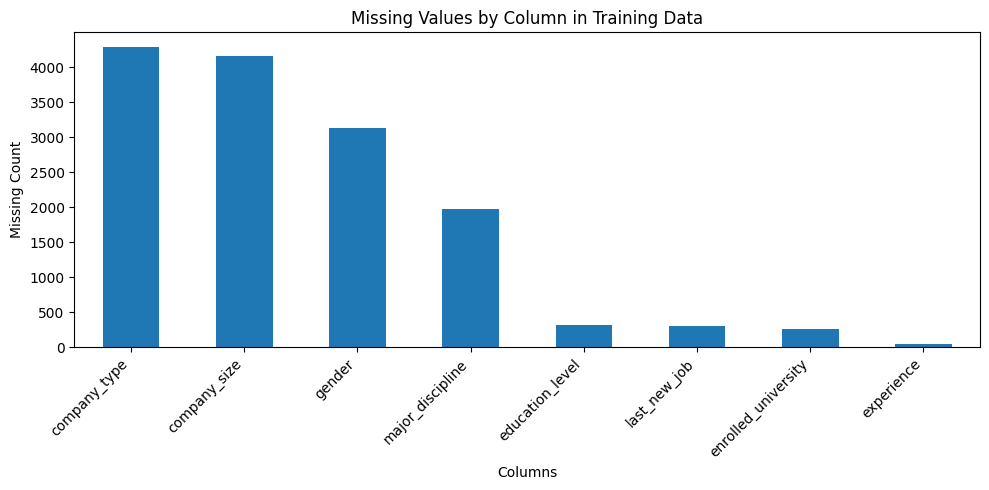

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

missing_plot = missing_train[missing_train > 0]

plt.figure(figsize=(10, 5))
missing_plot.plot(kind="bar")
plt.title("Missing Values by Column in Training Data")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 6. Examine the Target Distribution
If data is imbalanced, accuracy alone may be misleading, and additional metrics such as precision, recall, F1 score, and ROC AUC become more important.

In [8]:
# Display class counts and normalized class percentages
print("Training target distribution:")
display(train_df[TARGET_COL].value_counts())
display((train_df[TARGET_COL].value_counts(normalize=True) * 100).round(2))


Training target distribution:


target
0.0    10067
1.0     3343
Name: count, dtype: int64

target
0.0    75.07
1.0    24.93
Name: proportion, dtype: float64

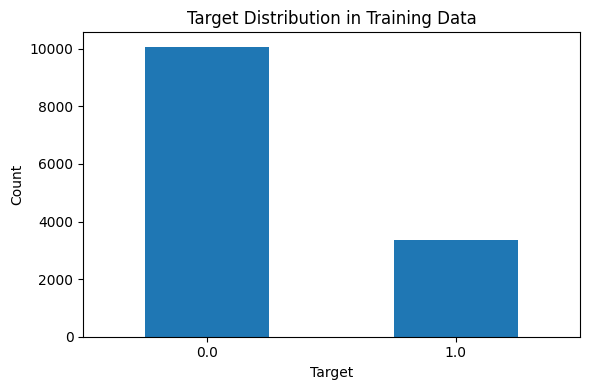

In [9]:
plt.figure(figsize=(6, 4))
train_df[TARGET_COL].value_counts().sort_index().plot(kind="bar")
plt.title("Target Distribution in Training Data")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 7. Generate Descriptive Statistics

In [10]:
# Summary statistics for numeric columns
print("Numeric summary on training data only:")
display(train_df.describe(include=[np.number]))

# Summary statistics for categorical columns
print("Categorical summary on training data only:")
display(train_df.describe(include=["object"]))


Numeric summary on training data only:


,enrollee_id,city_development_index,training_hours,target
count,13410.000000,13410.000000,13410.000000,13410.000000
mean,16955.244966,0.829891,65.102237,0.249292
std,9598.937815,0.122866,59.551523,0.432619
min,1.000000,0.448000,1.000000,0.000000
25%,8640.500000,0.740000,23.000000,0.000000
50%,17153.500000,0.910000,47.000000,0.000000
75%,25217.500000,0.920000,88.000000,0.000000
max,33377.000000,0.949000,336.000000,1.000000


Categorical summary on training data only:


/tmp/ipykernel_17649/1464755903.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(train_df.describe(include=["object"]))


,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
count,13410,10276,13410,13145,13094,11427,13362,9251,9125,13104
unique,122,3,2,3,5,6,22,8,6,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1
freq,3089,9286,9665,9680,8103,10125,2335,2122,6873,5566


#### Summary Interpretation

The descriptive statistics show that the training dataset includes both numerical and categorical variables with very different structures. Numerical fields such as `training_hours` and engineered experience related values vary widely in scale, while categorical columns contain multiple levels and some missing values. This confirms that the dataset needs a mixed preprocessing strategy rather than a single transformation for all columns.


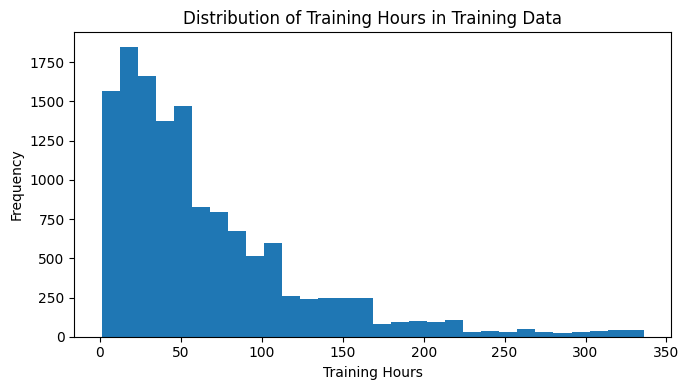

In [11]:
plt.figure(figsize=(7, 4))
train_df["training_hours"].dropna().plot(kind="hist", bins=30)
plt.title("Distribution of Training Hours in Training Data")
plt.xlabel("Training Hours")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


The histogram shows that `training_hours` is right skewed, with most observations concentrated at lower values and fewer candidates at very high values. This pattern supports the decision to use median imputation for missing values and also justifies applying a log transformation later to reduce skewness.


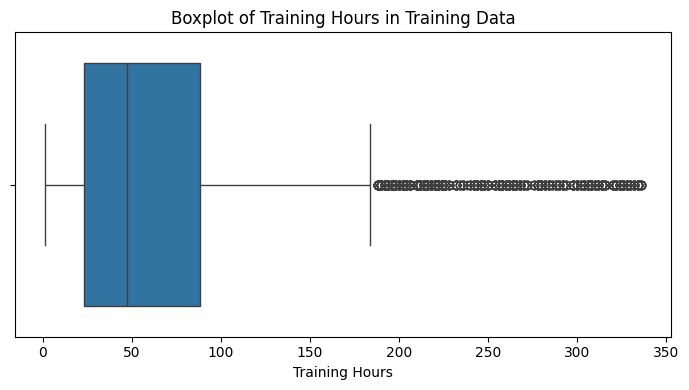

In [12]:
plt.figure(figsize=(7, 4))
sns.boxplot(x=train_df["training_hours"].dropna())
plt.title("Boxplot of Training Hours in Training Data")
plt.xlabel("Training Hours")
plt.tight_layout()
plt.show()


The boxplot makes extreme values in `training_hours` easier to spot than a histogram alone. This matters because strong outliers can distort scale sensitive models and can also make a skewed feature harder to interpret. This visual supports the later normalization step where a log transform is applied to stabilize the feature.


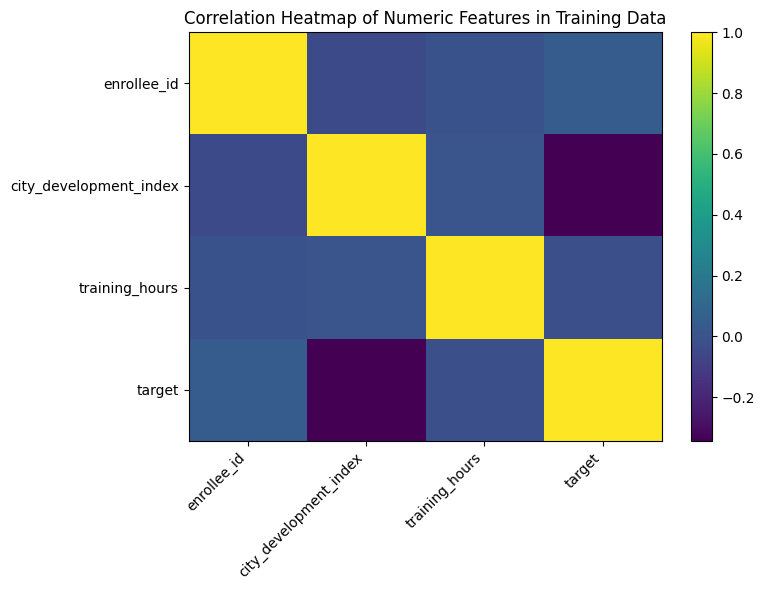

In [13]:
numeric_train = train_df.select_dtypes(include=[np.number])

if not numeric_train.empty:
    plt.figure(figsize=(8, 6))
    corr = numeric_train.corr()
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Heatmap of Numeric Features in Training Data")
    plt.tight_layout()
    plt.show()


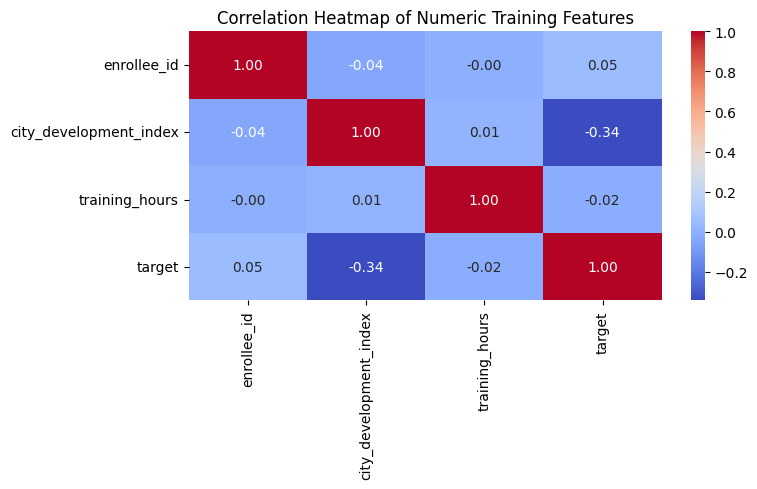

In [14]:
if not numeric_train.empty:
    plt.figure(figsize=(8, 5))
    sns.heatmap(numeric_train.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap of Numeric Training Features")
    plt.tight_layout()
    plt.show()


The correlation heatmap summarizes relationships among the numeric training features. Even when the correlations are moderate, this is still useful because it shows which variables move together and where additional engineered features may help a later model capture more predictive structure.


### 8. Inspect Raw Values in Special Categorical Columns

Some columns look categorical at first, but their values actually represent ordered numeric information or ranges.

This section inspects the raw values of:
- `company_size`
- `experience`
- `last_new_job`

**Why this matters**
These columns contain values such as:
- `<1`
- `>20`
- `never`
- `10/49`

These are not ready for modeling directly.  
They need custom cleaning rules before they can be used effectively.


In [15]:
# Review raw values to understand how custom cleaning should be done
print("Raw company_size unique values:")
display(pd.Series(sorted(train_df["company_size"].dropna().unique())).to_frame("company_size"))

print("Raw experience unique values:")
display(pd.Series(sorted(train_df["experience"].dropna().unique())).to_frame("experience"))

print("Raw last_new_job unique values:")
display(pd.Series(sorted(train_df["last_new_job"].dropna().unique())).to_frame("last_new_job"))


Raw company_size unique values:


,company_size
0,10/49
1,100-500
2,1000-4999
3,10000+
4,50-99
5,500-999
6,5000-9999
7,<10


Raw experience unique values:


,experience
0,1
1,10
2,11
3,12
4,13
5,14
6,15
7,16
8,17
9,18


Raw last_new_job unique values:


,last_new_job
0,1
1,2
2,3
3,4
4,>4
5,never


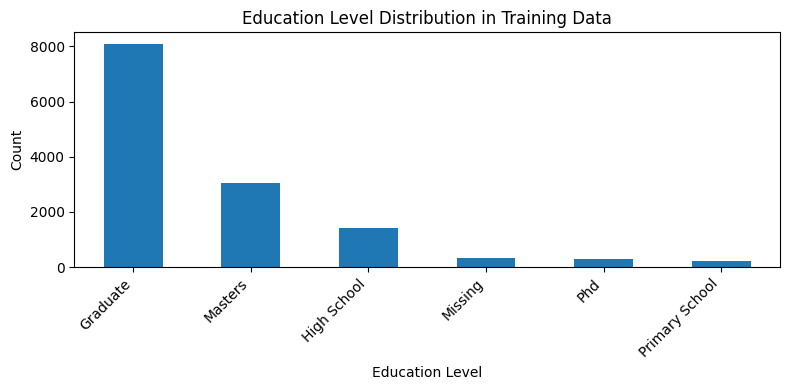

In [16]:
top_education = train_df["education_level"].fillna("Missing").value_counts()

plt.figure(figsize=(8, 4))
top_education.plot(kind="bar")
plt.title("Education Level Distribution in Training Data")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


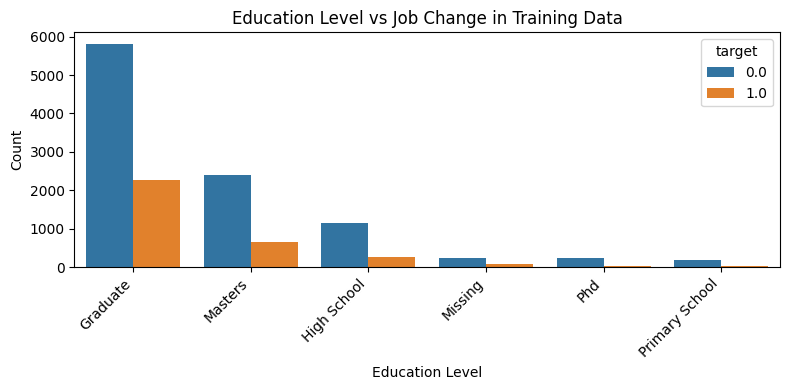

In [17]:
plt.figure(figsize=(8, 4))
education_plot_df = train_df.copy()
education_plot_df["education_level"] = education_plot_df["education_level"].fillna("Missing")
sns.countplot(
    data=education_plot_df,
    x="education_level",
    hue=TARGET_COL,
    order=education_plot_df["education_level"].value_counts().index
)
plt.title("Education Level vs Job Change in Training Data")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


This chart goes beyond simple category frequency and compares education level directly with the target outcome. It helps show whether certain education groups are more likely to look for a job change. This adds stronger exploratory value because it connects a feature to the machine learning objective rather than only describing the dataset.


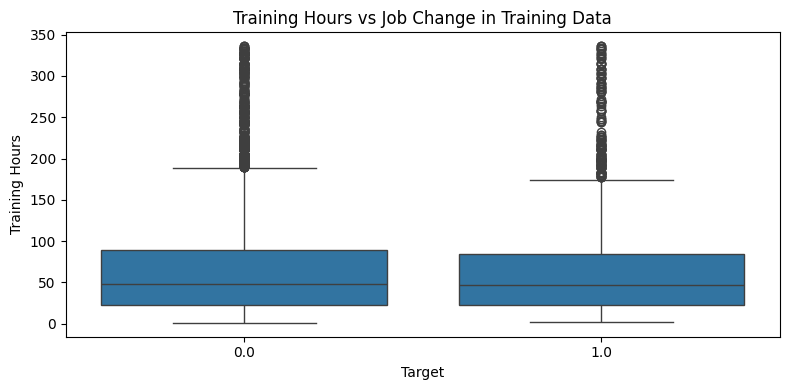

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=train_df, x=TARGET_COL, y="training_hours")
plt.title("Training Hours vs Job Change in Training Data")
plt.xlabel("Target")
plt.ylabel("Training Hours")
plt.tight_layout()
plt.show()


This chart shows whether candidates who changed jobs and candidates who stayed tend to have different training-hour patterns.


### 9. Explicit Missing Value Handling Plan

The midterm requirement asks for clear handling of NaN and null values.

In this notebook, missing values are handled in a reproducible preprocessing pipeline rather than manually editing the raw CSV. Numeric and categorical columns are treated differently because they represent different kinds of information.

**Planned strategy**
- Numeric columns: impute missing values with the median
- Categorical columns: impute missing values with the most frequent value

This section documents that plan before the actual pipeline is built.


In [56]:
# Show missing-value handling strategy in a concrete way
numeric_missing = X_train.select_dtypes(include=["number"]).isna().sum()
categorical_missing = X_train.select_dtypes(exclude=["number"]).isna().sum()

print("Numeric columns with missing values in training data:")
display(numeric_missing[numeric_missing > 0].sort_values(ascending=False).to_frame("missing_count"))

print("Categorical columns with missing values in training data:")
display(categorical_missing[categorical_missing > 0].sort_values(ascending=False).to_frame("missing_count"))

print("Planned imputation rules:")
display(pd.DataFrame({
    "data_type": ["numeric", "categorical"],
    "imputation_strategy": ["median", "most_frequent"]
}))


Numeric columns with missing values in training data:


,missing_count


Categorical columns with missing values in training data:


,missing_count
company_type,4285
company_size,4159
gender,3134
major_discipline,1983
education_level,316
last_new_job,306
enrolled_university,265
experience,48


Planned imputation rules:


,data_type,imputation_strategy
0,numeric,median
1,categorical,most_frequent


**Why median for numeric columns and mode for categorical columns**

Median imputation was kept for numeric columns because features such as `training_hours` are right skewed and contain outliers. The median is more robust than the mean in that situation. Mode imputation was kept only for the remaining low-cardinality nominal columns that are still categorical after the new encoding strategy.

**Updated encoding strategy to reduce unnecessary columns**

The encoding plan was revised to match the meaning of each feature instead of one-hot encoding every text column. High-cardinality identifiers such as `city` were removed. Binary fields such as `relevent_experience` were converted directly to `0/1`. Ordinal fields such as `education_level`, `company_size`, `experience`, and `last_new_job` were converted into ordered numeric values. Only low-cardinality nominal columns such as `gender`, `enrolled_university`, `major_discipline`, and `company_type` remain one-hot encoded. This reduces feature explosion and keeps the processed dataset easier to interpret.


### 10. Clean Special Values and Engineer New Features

Some columns contain values that are technically categorical strings but actually represent ordered numeric meaning. For example, `experience` includes values such as `<1` and `>20`, while `last_new_job` includes values such as `never` and `>4`. These are cleaned into structured numeric form so the model can use their meaning more effectively.

This section also fixes inconsistent formatting in `company_size` and creates engineered features that better represent the underlying information. The goal is to preserve meaning from the raw dataset while making the data more consistent and usable for machine learning.

**Key transformations**
- convert string-based experience values into numeric form
- convert string-based last job change values into numeric form
- fix inconsistent `company_size` labels
- extract a numeric city identifier
- create a ratio between training hours and experience
- create grouped bucket features for experience, training hours, and city development
- remove the ID column because it does not help generalization


In [76]:
# Convert experience strings like "<1" and ">20" into ordered numeric values
def parse_experience(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "<1":
        return 0
    if s == ">20":
        return 21
    return pd.to_numeric(s, errors="coerce")


# Convert last_new_job strings like "never" and ">4" into ordered numeric values
def parse_last_new_job(x):
    s = str(x).strip().lower()
    if s == "never":
        return 0
    if s == ">4":
        return 5
    # if pd.isna(x):
    #     return np.nan
    # Leave empties for now, will fill with median later
    return pd.to_numeric(s, errors="coerce")


# Fix inconsistent categorical formatting in company_size
def clean_company_size(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "10/49":
        return "10-49"
    return s

# def city_num(x):
#     s = x.removeprefix("city_")
#     return s

education_map = {
    "Primary School": 0,
    "High School": 1,
    "Graduate": 2,
    "Masters": 3,
    "Phd": 4
}

company_size_map = {
    "<10": 0,
    "10-49": 1,
    "50-99": 2,
    "100-500": 3,
    "500-999": 4,
    "1000-4999": 5,
    "5000-9999": 6,
    "10000+": 7
}

relevant_experience_map = {
    "No relevent experience": 0,
    "Has relevent experience": 1
}


# Apply all cleaning and engineered feature creation to a given DataFrame
def add_features(frame):
    d = frame.copy()

    # d["city_num"] = d["city"].apply(city_num)

    # Save untouched raw columns for later export before changing feature design
    d["company_size"] = d["company_size"].apply(clean_company_size)

    # Binary encoding
    d["relevent_experience"] = d["relevent_experience"].map(relevant_experience_map)

    # Ordinal encoding
    d["education_level"] = d["education_level"].map(education_map)
    d["company_size"] = d["company_size"].map(company_size_map)
    d["experience_num"] = d["experience"].apply(parse_experience)
    d["last_new_job_num"] = d["last_new_job"].apply(parse_last_new_job)

    # Compact engineered numeric features
    d["training_per_experience"] = d["training_hours"] / (d["experience_num"] + 1)
    d["training_hours_log1p"] = np.log1p(d["training_hours"].clip(lower=0))

    # Remove fields that would create too many or redundant encoded columns
    drop_cols = [
        "enrollee_id",      # identifier only
        # "city",             # high-cardinality categorical
        "experience",       # replaced by experience_num
        "last_new_job"      # replaced by last_new_job_num
    ]
    d = d.drop(columns=drop_cols)

    return d


# Apply feature engineering to train and test separately using the same logic
X_train_fe = add_features(X_train)
X_test_fe = add_features(X_test)

print("Engineered training shape:", X_train_fe.shape)
print("Columns after reduced-column strategy:")
print(X_train_fe.columns.tolist())


Engineered training shape: (13410, 14)
Columns after reduced-column strategy:
['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'company_size', 'company_type', 'training_hours', 'experience_num', 'last_new_job_num', 'training_per_experience', 'training_hours_log1p']


Additional feature engineering was kept intentionally compact so the processed dataset would stay useful and not explode into unnecessary columns. The revised strategy removes `city` entirely because it has very high cardinality, converts `relevent_experience` into a single binary column, converts ordinal features into ordered numeric values, and keeps only a small set of low-cardinality nominal features for one-hot encoding. This makes the final design easier to justify and closer to the professor's guidance.


In [77]:
# Group numeric experience into business-friendly levels for EDA only
# Removed from feedback for midterm ----------------------------------------------------------------------------------------

# def map_experience_level(x):
#     if pd.isna(x):
#         return "Missing"
#     if x <= 2:
#         return "Junior"
#     elif x <= 5:
#         return "Mid"
#     elif x <= 10:
#         return "Senior"
#     else:
#         return "Expert"

# X_train_fe["experience_level"] = X_train_fe["experience_num"].apply(map_experience_level)
# X_test_fe["experience_level"] = X_test_fe["experience_num"].apply(map_experience_level)

print("Reduced-column feature preview:")
display(
    X_train_fe[
        [
            # "city_num",
            "relevent_experience",
            "education_level",
            "experience_num",
            "company_size",     
            "last_new_job_num",
            "training_per_experience",
            "training_hours_log1p",
            # "experience_level"
        ]
    ].head()
)


Reduced-column feature preview:


,relevent_experience,education_level,experience_num,company_size,last_new_job_num,training_per_experience,training_hours_log1p
10819,1,2.0,16.0,4.0,5.0,2.823529,3.891820
7306,1,2.0,21.0,7.0,5.0,5.772727,4.852030
17738,1,2.0,16.0,1.0,1.0,1.705882,3.401197
4838,1,2.0,17.0,3.0,2.0,0.222222,1.609438
5978,1,2.0,8.0,0.0,2.0,3.555556,3.496508


In [39]:
# Removed from feedback for midterm ----------------------------------------------------------------------------------------


# train_fe_preview = X_train_fe.copy()
# train_fe_preview[TARGET_COL] = y_train.reset_index(drop=True).values

# plt.figure(figsize=(8, 4))
# sns.countplot(
#     data=train_fe_preview,
#     x="experience_level",
#     hue=TARGET_COL,
#     order=["Junior", "Mid", "Senior", "Expert", "Missing"]
    
# )
# plt.title("Experience Level vs Job Change")
# plt.xlabel("Experience Level")
# plt.ylabel("Count")
# plt.tight_layout()
# plt.show()


This feature engineering step now stays focused on interpretability rather than creating many extra columns. `experience_level` is retained as a small categorical summary for analysis, while the main model-ready variables use compact numeric encoding for binary and ordinal fields.


### 11. Normalize a Skewed Numeric Feature

Some numeric features may be skewed, meaning their values are not distributed evenly.  
A common example is training hours, where many candidates may have low values and a smaller number may have very high values.

This section creates a log-transformed version of `training_hours` using `log1p`.

**Why use `log1p`**
- it reduces the effect of very large values
- it keeps zero safe because `log1p(0) = 0`
- it can make the feature easier for some models to use

This transformation is especially useful because highly skewed variables can compress most observations into a narrow range while leaving a few extreme values very far away. A log transform helps make the feature more stable and easier for some models to learn from.


In [59]:
# Create working copies after feature engineering
X_train_ready = X_train_fe.copy()
X_test_ready = X_test_fe.copy()

print("Model-ready working copies created with reduced feature count.")


Model-ready working copies created with reduced feature count.


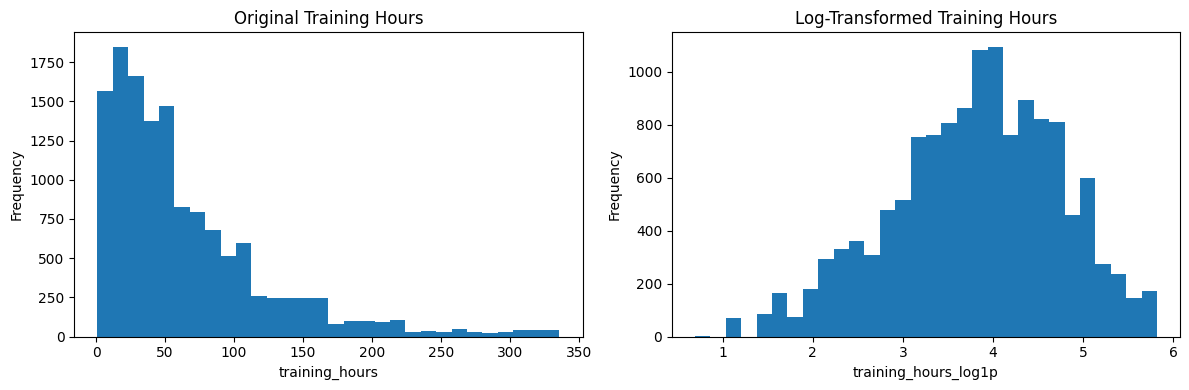

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

X_train_ready["training_hours"].dropna().plot(kind="hist", bins=30, ax=axes[0])
axes[0].set_title("Original Training Hours")
axes[0].set_xlabel("training_hours")
axes[0].set_ylabel("Frequency")

X_train_ready["training_hours_log1p"].dropna().plot(kind="hist", bins=30, ax=axes[1])
axes[1].set_title("Log-Transformed Training Hours")
axes[1].set_xlabel("training_hours_log1p")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


In [84]:
print(X_train_ready["education_level"].unique().tolist())

[2.0, 3.0, 1.0, nan, 4.0, 0.0]


### 12. Identify Numeric and Categorical Features, split out ordinal features

After revising the encoding strategy, many formerly categorical fields are now compact numeric columns. Only the remaining low-cardinality nominal columns stay categorical for one-hot encoding. This should materially reduce the final processed column count.


In [91]:
# Detect feature types automatically from the prepared training set
numeric_features = X_train_ready.select_dtypes(include=["number"]).columns.tolist()
# manually change some cols after the midterm feedback -------------------------------------------------------------------------------------
numeric_features.remove('city_development_index')               #splitting out as the col is already scaled 0-1
numeric_features.remove('relevent_experience')                  #moving to ordinal feature
numeric_features.remove('education_level')                      #moving to ordinal feature
numeric_features.remove('last_new_job_num')                     #moving to ordinal feature
numeric_features.remove('company_size')                         #moving to ordinal feature
numeric_features.remove('experience_num')                       #moving to ordinal feature
numeric_features.remove('training_hours')                       #only including log1p transformed col
numeric_features_skip_transformer = ['city_development_index']  #using the original col

categorical_features = X_train_ready.select_dtypes(include=["object", "category"]).columns.tolist()

#city numbers
# arr = [str(i) for i in range(1, 181)]
arr = [f"city_{i}" for i in range(1, 181)]


# define known ordinal patterns
ordinal_mappings = {
    "gender": ['Male', 'Female', 'Other'],
    "enrolled_university": ["no_enrollment", "Part time course", "Full time course"],
    # "education_level": ["Primary School", "High School", "Graduate", "Masters", "Phd"],
    "education_level": [0.0, 1.0, 2.0, 3.0, 4.0],
    "last_new_job_num": [0.0, 1.0, 2.0, 3.0, 4.0, 5.0],
    "company_size": [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0],
    "experience_num": [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0],
    "relevent_experience": [0, 1],
    # "experience_level": ["Missing", "Junior", "Mid", "Senior", "Expert"],
    "city": arr,
}

ordinal_features = [col for col in categorical_features if col in ordinal_mappings]
ordinal_features.append('relevent_experience')
ordinal_features.append('education_level')
ordinal_features.append('last_new_job_num')
ordinal_features.append('company_size')
ordinal_features.append('experience_num')
# ordinal_features.remove('experience_level')
nominal_features = [col for col in categorical_features if col not in ordinal_features]

ordinal_categories = [
    ordinal_mappings[col] for col in ordinal_features
]

print("Numeric features:")
print(numeric_features)

print("\nNumeric features skipping transformer:")
print(numeric_features_skip_transformer)

print("\nOrdinal features:")
print(ordinal_features)

print("\nNominal features:")
print(nominal_features)



Numeric features:
['training_per_experience', 'training_hours_log1p']

Numeric features skipping transformer:
['city_development_index']

Ordinal features:
['city', 'gender', 'enrolled_university', 'relevent_experience', 'education_level', 'last_new_job_num', 'company_size', 'experience_num']

Nominal features:
['major_discipline', 'company_type']


/tmp/ipykernel_17649/3164271336.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train_ready.select_dtypes(include=["object", "category"]).columns.tolist()


### 13. Build the Preprocessing Pipeline

The preprocessing pipeline is built so that all transformations are applied in a controlled and reproducible way.

**Numeric pipeline**
- fill missing values using the median
- standardize values using `StandardScaler`

**Categorical pipeline**
- fill missing values using the most frequent category
- apply one hot encoding

Most importantly, the pipeline is fit only on the training data and then applied to the testing data. This is the correct workflow because it prevents data leakage and ensures that the test set stays unseen during preprocessing decisions.

Using a pipeline also makes the workflow cleaner, easier to reuse, and more reliable for future modeling.

#### Note on one hot encoding

Categorical variables are transformed using one hot encoding, where each category becomes a separate binary column. A value of 1 means the record belongs to that category, and a value of 0 means it does not. This preserves category membership without forcing an artificial numeric ranking between categories.


In [92]:
# Numeric preprocessing:
# 1. fill missing numeric values with the median
# 2. scale numeric features to a standard range
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Ordinal preprocessing:
# 1. fill missing values with most frequent
# 2. apply categories 

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories))
])

# Categorical preprocessing:
# 1. fill missing category values with the most frequent category
# 2. one-hot encode only the remaining low-cardinality nominal values
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine numeric and categorical preprocessing into one transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("cat", categorical_transformer, nominal_features)
    ]
)


### 14. Apply Preprocessing to Training and Testing Data

Now the preprocessing pipeline is applied.

**Important rule**

The pipeline is:
- **fit** on the training data
- then **applied** to the test data

This is a very important machine learning rule because the test data must remain unseen during learning.

After transformation:
- missing values should be handled
- categorical values should become numeric columns
- numeric features should be scaled


In [95]:
# Fit the preprocessor on training data and transform it
X_train_clean = preprocessor.fit_transform(X_train_ready)

# Apply the already-fitted preprocessor to test data
X_test_clean = preprocessor.transform(X_test_ready)

# --- Get feature names from each transformer ---

# Numeric features (unchanged)
num_feature_names = list(numeric_features)

# num_feature_names_skip_transformer = list(numeric_features_skip_transformer)

# Ordinal features (stay same names)
# ord_feature_names = list(ordinal_features)
ord_feature_names = [f"{col}_ordinal" for col in ordinal_features]

# Nominal (one-hot encoded)
ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(nominal_features)

# --- Combine all feature names in correct order ---
feature_names = (
    num_feature_names +
    ord_feature_names +
    list(cat_feature_names)
)

# Convert processed arrays back to DataFrames
train_processed_df = pd.DataFrame(X_train_clean, columns=feature_names)
train_processed_df["city_development_index"] = X_train_ready["city_development_index"].values
test_processed_df = pd.DataFrame(X_test_clean, columns=feature_names)
test_processed_df["city_development_index"] = X_test_ready["city_development_index"].values

# Add target column back
train_processed_df[TARGET_COL] = y_train.reset_index(drop=True).values
test_processed_df[TARGET_COL] = y_test.reset_index(drop=True).values

print("Processed training shape:", train_processed_df.shape)
print("Processed testing shape:", test_processed_df.shape)
display(train_processed_df.head())


Processed training shape: (13410, 24)
Processed testing shape: (2874, 24)


,training_per_experience,training_hours_log1p,city_ordinal,gender_ordinal,enrolled_university_ordinal,relevent_experience_ordinal,education_level_ordinal,last_new_job_num_ordinal,company_size_ordinal,experience_num_ordinal,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,city_development_index,target
0,-0.415998,0.098653,64.0,0.0,2.0,1.0,2.0,5.0,4.0,16.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.802,0.0
1,-0.251032,1.117613,102.0,0.0,0.0,1.0,2.0,5.0,7.0,21.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.920,0.0
2,-0.478514,-0.421989,27.0,0.0,0.0,1.0,2.0,1.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.939,0.0
3,-0.561504,-2.323378,102.0,0.0,0.0,1.0,2.0,2.0,3.0,17.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.920,0.0
4,-0.375051,-0.320847,49.0,0.0,0.0,1.0,2.0,2.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.896,0.0


### 15. Compare Raw and Cleaned Training Data

This section compares the dataset before and after preprocessing.

The comparison shows:
- number of rows
- number of columns
- total number of missing values

**Why the number of columns increases**

After one-hot encoding, each category becomes one or more separate numeric columns.  
That is why the cleaned dataset usually has many more columns than the raw dataset.


In [96]:
# Count missing values before and after preprocessing
before_missing = train_df.isna().sum().sum()
after_missing = train_processed_df.isna().sum().sum()

# Summarize the difference between raw and processed training data
comparison_df = pd.DataFrame({
    'stage': ['raw training data', 'processed training data'],
    'rows': [train_df.shape[0], train_processed_df.shape[0]],
    'columns': [train_df.shape[1], train_processed_df.shape[1]],
    'missing_values': [before_missing, after_missing]
})

display(comparison_df)


,stage,rows,columns,missing_values
0,raw training data,13410,14,14496
1,processed training data,13410,24,0


In [97]:
comparison_summary = pd.DataFrame({
    "Aspect": [
        "Rows in training set",
        "Columns in training set",
        "Total missing values",
        "Categorical columns",
        "Numeric columns"
    ],
    "Before Processing": [
        train_df.shape[0],
        train_df.shape[1],
        int(train_df.isna().sum().sum()),
        train_df.select_dtypes(include=["object", "category"]).shape[1],
        train_df.select_dtypes(include=["number"]).shape[1]
    ],
    "After Processing": [
        train_processed_df.shape[0],
        train_processed_df.shape[1],
        int(train_processed_df.isna().sum().sum()),
        0,
        train_processed_df.shape[1]
    ]
})

display(comparison_summary)


/tmp/ipykernel_17649/576114693.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.select_dtypes(include=["object", "category"]).shape[1],


,Aspect,Before Processing,After Processing
0,Rows in training set,13410,13410
1,Columns in training set,14,24
2,Total missing values,14496,0
3,Categorical columns,10,0
4,Numeric columns,4,24


This before and after summary makes the transformation easier to evaluate. The raw training data contains mixed data types and missing values, while the processed training data is fully numeric and ready for machine learning. The revised encoding strategy also reduces unnecessary column growth by avoiding full one-hot encoding on high-cardinality and ordinal variables.


In [98]:
print("Raw training sample:")
display(train_df.head())

print("Processed training sample:")
display(train_processed_df.head())


Raw training sample:


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
10819,18126,city_65,0.802,NaN,Has relevent experience,Full time course,Graduate,STEM,16,500-999,Pvt Ltd,>4,48,0.0
7306,12352,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,Humanities,>20,10000+,Pvt Ltd,>4,127,0.0
17738,17615,city_28,0.939,Male,Has relevent experience,no_enrollment,Graduate,STEM,16,10/49,Pvt Ltd,1,29,0.0
4838,14072,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,17,100-500,Pvt Ltd,2,4,0.0
5978,22784,city_50,0.896,NaN,Has relevent experience,no_enrollment,Graduate,STEM,8,<10,Public Sector,2,32,0.0


Processed training sample:


,training_per_experience,training_hours_log1p,city_ordinal,gender_ordinal,enrolled_university_ordinal,relevent_experience_ordinal,education_level_ordinal,last_new_job_num_ordinal,company_size_ordinal,experience_num_ordinal,major_discipline_Arts,major_discipline_Business Degree,major_discipline_Humanities,major_discipline_No Major,major_discipline_Other,major_discipline_STEM,company_type_Early Stage Startup,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,city_development_index,target
0,-0.415998,0.098653,64.0,0.0,2.0,1.0,2.0,5.0,4.0,16.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.802,0.0
1,-0.251032,1.117613,102.0,0.0,0.0,1.0,2.0,5.0,7.0,21.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.920,0.0
2,-0.478514,-0.421989,27.0,0.0,0.0,1.0,2.0,1.0,1.0,16.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.939,0.0
3,-0.561504,-2.323378,102.0,0.0,0.0,1.0,2.0,2.0,3.0,17.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.920,0.0
4,-0.375051,-0.320847,49.0,0.0,0.0,1.0,2.0,2.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.896,0.0


In [99]:
before_types = train_df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")
after_types = train_processed_df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")

print("Raw training data types:")
display(before_types)

print("Clean training data types:")
display(after_types)


Raw training data types:


,dtype,count
0,str,10
1,int64,2
2,float64,2


Clean training data types:


,dtype,count
0,float64,24


### 16. Final Missing Value Verification

Before training models, the notebook performs one final check to confirm that no missing values remain.

This is important because most machine learning models require complete numeric input.


In [100]:
# Confirm that no missing values remain after preprocessing
print("Any missing values left in processed training data?", train_processed_df.isna().sum().sum())
print("Any missing values left in processed testing data?", test_processed_df.isna().sum().sum())


Any missing values left in processed training data? 0
Any missing values left in processed testing data? 0


### 17. Prepare Final Inputs for Modeling

This section separates the cleaned feature matrix from the target column.

The models should only receive:
- input features as `X`
- target labels as `y`

The cleaned train and test sets are now ready for classification experiments.


In [101]:
# Remove target column so only model input features remain
X_train_model = train_processed_df.drop(columns=[TARGET_COL])
X_test_model = test_processed_df.drop(columns=[TARGET_COL])

print("Model training feature shape:", X_train_model.shape)
print("Model testing feature shape:", X_test_model.shape)


Model training feature shape: (13410, 23)
Model testing feature shape: (2874, 23)


#### Machine Learning Problem This Dataset Can Solve

This dataset is designed for a binary classification problem: predicting whether a candidate is likely to look for a new job. After cleaning and preprocessing, the dataset can be used to train classification models that estimate job change probability from demographic, educational, and professional features.

This type of prediction can support workforce planning, hiring strategy, employee retention analysis, and talent risk assessment. The preparation work in this notebook ensures that the final dataset is structured correctly for those machine learning tasks.


### 18. Train and Compare Baseline Models

This section trains multiple classification models and compares their performance on the test set.

**Models used**

- Baseline Logistic Regression
- Balanced Logistic Regression
- Random Forest

**Why compare multiple models**

Different models can perform differently on the same dataset.  
Comparing several models helps identify which one captures the job change pattern more effectively.

**Metrics used**

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC

Using several metrics gives a more complete view than accuracy alone.


In [145]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
# Store results for all candidate models
results = []

# Logistic Regression
# Decision Tree Classifier
# Random Forest Classifier
# Gradient Boosting Classifier (e.g., XGBoost or LightGBM)
# K-Nearest Neighbors Classifier
# Support Vector Classifier (SVC3)

# Define baseline models for comparison
models = {
    # "Baseline Logistic Regression": LogisticRegression(max_iter=2000),
    "Balanced Logistic Regression": LogisticRegression(
        # max_iter=2000, 
        class_weight="balanced",
        penalty="l2",        # standard regularization
        C=1.0,               # inverse regularization strength
        solver="lbfgs",      # good default
        max_iter=2000,       # avoids convergence warnings
        random_state=42
    ),
    "Decision Tree Classifier": DecisionTreeClassifier(
        max_depth=5,          # limit complexity
        min_samples_split=10, # require more samples to split
        min_samples_leaf=5,   # smoother leaves
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        n_jobs=-1
    ),
    "Gradient Boosting Classifier": GradientBoostingClassifier(
        n_estimators=200,     # number of trees
        learning_rate=0.05,   # smaller = more stable
        max_depth=3,          # weak learners
        subsample=0.8,        # adds randomness, reduces overfitting
        random_state=42
    ),
    "K-Nearest Neighbors Classifier": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",   # closer neighbors matter more
        metric="minkowski",   # standard Euclidean
        p=2
    ),
    "Support Vector Classifier": SVC( 
        probability=True,
        kernel="rbf",     # most commonly best
        C=1.0,            # regularization
        gamma="scale",    # automatic, usually good
        random_state=42,
        class_weight='balanced'
    )

}

# # Train each model, predict on test data, and collect performance metrics
# for model_name, model in models.items():
#     model.fit(X_train_model, y_train.reset_index(drop=True))
#     pred = model.predict(X_test_model)
#     proba = model.predict_proba(X_test_model)[:, 1]

#     results.append({
#         "model": model_name,
#         "accuracy": round(accuracy_score(y_test, pred), 4),
#         "precision": round(precision_score(y_test, pred), 4),
#         "recall": round(recall_score(y_test, pred), 4),
#         "f1_score": round(f1_score(y_test, pred), 4),
#         "roc_auc": round(roc_auc_score(y_test, proba), 4),
#     })

# # Rank models by ROC AUC first, then F1 score
# results_df = pd.DataFrame(results).sort_values(by=["roc_auc", "f1_score"], ascending=False)
# display(results_df)

for model_name, model in models.items():
    model.fit(X_train_model, y_train.reset_index(drop=True))
    pred = model.predict(X_test_model)

    # Handle probability safely
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_test_model)[:, 1]
    else:
        # fallback for models like SVC without probability (if turned off)
        proba = model.decision_function(X_test_model)

    results.append({
        "model": model_name,
        "accuracy": round(accuracy_score(y_test, pred), 4),
        "precision": round(precision_score(y_test, pred, zero_division=0), 4),
        "recall": round(recall_score(y_test, pred, zero_division=0), 4),
        "f1_score": round(f1_score(y_test, pred, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_test, proba), 4),
    })

results_df = pd.DataFrame(results).sort_values(
    by=["roc_auc", "f1_score"], ascending=False
)

display(results_df)




/home/rubix/workspace/ITAI-1371_Mid_Term_EDA_Group_ML_19179_3/notebooks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,accuracy,precision,recall,f1_score,roc_auc
3,Gradient Boosting Classifier,0.7818,0.5836,0.4379,0.5004,0.7952
2,Random Forest,0.7804,0.5557,0.5983,0.5762,0.7918
1,Decision Tree Classifier,0.7829,0.5876,0.4351,0.5000,0.7725
0,Balanced Logistic Regression,0.7105,0.4461,0.6639,0.5336,0.7423
4,K-Nearest Neighbors Classifier,0.7429,0.4813,0.3947,0.4337,0.7093
5,Support Vector Classifier,0.7074,0.4182,0.4421,0.4298,0.6664


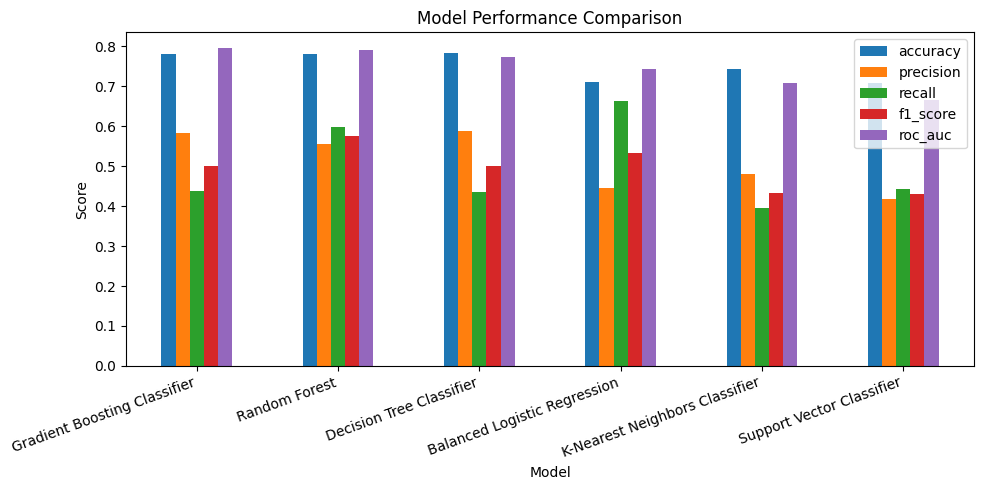

In [146]:
results_plot = results_df.set_index("model")[["accuracy", "precision", "recall", "f1_score", "roc_auc"]]

results_plot.plot(kind="bar", figsize=(10, 5))
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### 19. Validate Stronger Models with Cross Validation

A single train and test split gives one view of performance, but it may still be influenced by the exact split.

This section uses 5-fold stratified cross validation on the training data to estimate how consistently the stronger models perform.

**Why use cross validation**

It helps answer this question:  
Does the model perform well only on one split, or does it stay strong across multiple training and validation folds?

**Metrics tracked**

- ROC AUC
- F1 Score
- Recall
- Precision


In [139]:
# Create stratified folds to preserve target balance in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validate the stronger candidate models
cv_models = {
    "Balanced Logistic Regression": LogisticRegression(
        # max_iter=2000, 
        class_weight="balanced",
        penalty="l2",        # standard regularization
        C=1.0,               # inverse regularization strength
        solver="lbfgs",      # good default
        max_iter=2000,       # avoids convergence warnings
        random_state=42
    ),
    "Decision Tree Classifier": DecisionTreeClassifier(
        max_depth=5,          # limit complexity
        min_samples_split=10, # require more samples to split
        min_samples_leaf=5,   # smoother leaves
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced_subsample",
        min_samples_leaf=2,
        n_jobs=-1
    ),
    "Gradient Boosting Classifier": GradientBoostingClassifier(
        n_estimators=200,     # number of trees
        learning_rate=0.05,   # smaller = more stable
        max_depth=3,          # weak learners
        subsample=0.8,        # adds randomness, reduces overfitting
        random_state=42
    ),
    "K-Nearest Neighbors Classifier": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",   # closer neighbors matter more
        metric="minkowski",   # standard Euclidean
        p=2
    ),
    "Support Vector Classifier": SVC( 
        probability=True,
        kernel="rbf",     # most commonly best
        C=1.0,            # regularization
        gamma="scale",    # automatic, usually good
        random_state=42,
        class_weight='balanced'
    )
}

cv_rows = []

# Run cross validation and collect mean scores
for model_name, model in cv_models.items():
    scores = cross_validate(
        model,
        X_train_model,
        y_train.reset_index(drop=True),
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "roc_auc": "roc_auc",
            "f1": "f1",
            "recall": "recall",
            "precision": "precision",
        },
        n_jobs=None
    )

    cv_rows.append({
        "model": model_name,
        "accuracy": round(scores["test_accuracy"].mean(), 4),
        "cv_roc_auc_mean": round(scores["test_roc_auc"].mean(), 4),
        "cv_f1_mean": round(scores["test_f1"].mean(), 4),
        "cv_recall_mean": round(scores["test_recall"].mean(), 4),
        "cv_precision_mean": round(scores["test_precision"].mean(), 4),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by="cv_roc_auc_mean", ascending=False)
display(cv_results_df)


/home/rubix/workspace/ITAI-1371_Mid_Term_EDA_Group_ML_19179_3/notebooks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/rubix/workspace/ITAI-1371_Mid_Term_EDA_Group_ML_19179_3/notebooks/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/rubix/workspace/ITAI-1371_Mid_Term_EDA_Group_ML_19179_3/notebooks/.venv/

,model,accuracy,cv_roc_auc_mean,cv_f1_mean,cv_recall_mean,cv_precision_mean
3,Gradient Boosting Classifier,0.7797,0.7842,0.4744,0.3987,0.5857
2,Random Forest,0.7738,0.7777,0.5547,0.5654,0.5448
1,Decision Tree Classifier,0.7785,0.7602,0.4545,0.3715,0.5878
0,Balanced Logistic Regression,0.7092,0.7333,0.5247,0.6440,0.4428
4,K-Nearest Neighbors Classifier,0.7428,0.6901,0.4193,0.3724,0.4799
5,Support Vector Classifier,0.7060,0.6638,0.4159,0.4203,0.4121


### 19.5 Ensemble Model

Using top 3 models by performance:

- Gradient Boosting Classifier
- Random Forest Classifier
- Decision Tree Classifier


In [141]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ("gb", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            random_state=42
        )),
        ("rf", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1
        )),
        ("dt", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=5,
            random_state=42
        ))
    ],
    voting="soft"
)

voting_clf.fit(X_train_model, y_train.reset_index(drop=True))


pred = voting_clf.predict(X_test_model)

proba = voting_clf.predict_proba(X_test_model)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred, zero_division=0))
print("Recall:", recall_score(y_test, pred, zero_division=0))
print("F1:", f1_score(y_test, pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, proba))

Accuracy: 0.7856645789839944
Precision: 0.5866209262435678
Recall: 0.4769874476987448
F1: 0.5261538461538462
ROC AUC: 0.79594896832925


### 19.75 Bayesian Model


In [149]:
from sklearn.naive_bayes import GaussianNB

models = {
    "gb": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    ),
    "rf": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ),
    "dt": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=5,
        random_state=42
    ),
    "nb": GaussianNB()
}

# Fit models
for model in models.values():
    model.fit(X_train_model, y_train.reset_index(drop=True))


val_probs = []

for name, model in models.items():
    proba = model.predict_proba(X_test_model)[:, 1]
    val_probs.append(proba)

val_probs = np.array(val_probs)  # shape: (n_models, n_samples)

from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score

def objective(weights):
    weights = np.array(weights)
    weights = weights / weights.sum()  # normalize

    blended = np.dot(weights, val_probs)
    return -roc_auc_score(y_test, blended)  # negative because we minimize

# initial equal weights
init_weights = np.ones(val_probs.shape[0]) / val_probs.shape[0]

# bounds: weights between 0 and 1
bounds = [(0, 1)] * len(init_weights)

# constraint: weights sum to 1
constraints = {"type": "eq", "fun": lambda w: np.sum(w) - 1}

result = minimize(objective, init_weights, bounds=bounds, constraints=constraints)

optimal_weights = result.x / result.x.sum()

print("Optimal weights:", optimal_weights)

test_probs = []

for model in models.values():
    proba = model.predict_proba(X_test_model)[:, 1]
    test_probs.append(proba)

test_probs = np.array(test_probs)

# weighted prediction
final_proba = np.dot(optimal_weights, test_probs)
final_pred = (final_proba >= 0.5).astype(int) 

print("Optimized Ensemble Results")
print("Accuracy:", accuracy_score(y_test, final_pred))
print("Precision:", precision_score(y_test, final_pred, zero_division=0))
print("Recall:", recall_score(y_test, final_pred, zero_division=0))
print("F1:", f1_score(y_test, final_pred, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, final_proba))

Optimal weights: [0.25 0.25 0.25 0.25]
Optimized Ensemble Results
Accuracy: 0.7874043145441892
Precision: 0.5833333333333334
Recall: 0.5174337517433751
F1: 0.5484109386548411
ROC AUC: 0.7793283067228168


### 20. Evaluate the Best Model in Detail

After comparing the candidate models, this section selects the best one and reports detailed performance on the test set.

**Detailed outputs include**

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC
- Confusion Matrix
- Classification Report

**Why this matters**
The confusion matrix and classification report help explain not only how often the model is right, but also what kinds of mistakes it makes.


In [128]:
# Select the top-ranked model from the results table
best_model_name = cv_results_df.iloc[0]["model"]
best_model = models[best_model_name]

# Predict labels and probabilities for final evaluation
best_pred = best_model.predict(X_test_model)
best_proba = best_model.predict_proba(X_test_model)[:, 1]

# Print detailed evaluation metrics
print("Selected best model:", best_model_name)
print("Accuracy:", round(accuracy_score(y_test, best_pred), 4))
print("Precision:", round(precision_score(y_test, best_pred), 4))
print("Recall:", round(recall_score(y_test, best_pred), 4))
print("F1 Score:", round(f1_score(y_test, best_pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, best_proba), 4))

# Show confusion matrix and full classification report
print("\nConfusion Matrix:\n", confusion_matrix(y_test, best_pred))
print("\nClassification Report:\n", classification_report(y_test, best_pred))


Selected best model: Gradient Boosting Classifier
Accuracy: 0.7818
Precision: 0.5836
Recall: 0.4379
F1 Score: 0.5004
ROC AUC: 0.7952

Confusion Matrix:
 [[1933  224]
 [ 403  314]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      2157
         1.0       0.58      0.44      0.50       717

    accuracy                           0.78      2874
   macro avg       0.71      0.67      0.68      2874
weighted avg       0.77      0.78      0.77      2874



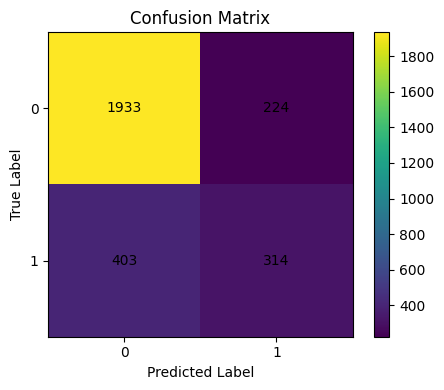

In [129]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], [0, 1])
plt.yticks([0, 1], [0, 1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


### 21. Interpretation of Results

The results show that careful preparation matters as much as model choice. This dataset contains mixed data types, missing values, inconsistent formatting, and string based numeric ranges, so raw input alone would not be reliable for modeling.

The preprocessing workflow improved the dataset by converting ambiguous values into structured form, reducing skew in `training_hours`, encoding categorical variables, and ensuring that no preprocessing knowledge was taken from the testing data before evaluation.

From a machine learning perspective, this cleaned dataset is now suitable for a binary classification task that predicts job change likelihood. From a data engineering perspective, the project demonstrates how to turn a raw Kaggle dataset into a reproducible and model ready dataset while preserving the separation between training and testing data.

#### Machine Learning Use Case

This cleaned dataset is suitable for a binary classification problem where the goal is to predict whether a candidate is likely to change jobs. The target variable is `target`, where `0` means the candidate is not looking for a job change and `1` means the candidate is likely to change jobs.

This problem is useful for HR analytics because organizations can use the model to identify retention risk, understand which employee profiles are more likely to leave, and support better workforce planning decisions.

The notebook prepares the data for this classification task by handling missing values, transforming skewed numeric data, encoding categorical variables, scaling numeric features, and generating engineered features. These steps make the dataset suitable for models such as Logistic Regression, Random Forest, and Gradient Boosting.

For evaluation, accuracy alone is not enough. Precision, recall, F1 score, and ROC AUC all matter because they provide a fuller view of model performance, especially when one class may be more important to detect correctly than the other.



### 22. Save the Raw Split and Processed Datasets

Because the professor requires the testing dataset to remain untouched, this notebook now saves both versions:

- an untouched raw split for testing, created immediately after the original 70/30 split
- a processed training dataset and processed testing dataset created only after fitting transformations on the training data

The processed file names were also renamed to make their purpose explicit and avoid confusion.


In [150]:
# Choose output directory based on environment
repo_output = Path('/data/processed/')
if repo_output.parent.exists():
    OUTPUT_DIR = repo_output
else:
    OUTPUT_DIR = Path.cwd() / "output"

# Create the folder if it does not already exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Save untouched raw train/test splits for traceability
train_raw_split_df = X_train.copy()
train_raw_split_df[TARGET_COL] = y_train.values

test_raw_split_df = X_test.copy()
test_raw_split_df[TARGET_COL] = y_test.values

# Define output file names
train_raw_out = OUTPUT_DIR / 'hr_jobchange_train_raw_split.csv'
test_raw_out = OUTPUT_DIR / 'hr_jobchange_test_raw_split.csv'
train_processed_out = OUTPUT_DIR / 'hr_jobchange_train_processed.csv'
test_processed_out = OUTPUT_DIR / 'hr_jobchange_test_processed.csv'

# Save all versions
train_raw_split_df.to_csv(train_raw_out, index=False)
test_raw_split_df.to_csv(test_raw_out, index=False)
train_processed_df.to_csv(train_processed_out, index=False)
test_processed_df.to_csv(test_processed_out, index=False)

print('Saved raw split:', train_raw_out)
print('Saved raw split:', test_raw_out)
print('Saved processed:', train_processed_out)
print('Saved processed:', test_processed_out)


Saved raw split: /home/rubix/workspace/ITAI1371_Final/notebooks/output/hr_jobchange_train_raw_split.csv
Saved raw split: /home/rubix/workspace/ITAI1371_Final/notebooks/output/hr_jobchange_test_raw_split.csv
Saved processed: /home/rubix/workspace/ITAI1371_Final/notebooks/output/hr_jobchange_train_processed.csv
Saved processed: /home/rubix/workspace/ITAI1371_Final/notebooks/output/hr_jobchange_test_processed.csv
